In [ ]:
# In colab run this cell first to setup the file structure!
%cd /content
!rm -rf MOL518-Intro-to-Data-Analysis

!git clone https://github.com/shaevitz/MOL518-Intro-to-Data-Analysis.git
%cd MOL518-Intro-to-Data-Analysis/Precept_7

# MOL518 Precept: Dense Optical Flow and PIV

## What we'll do today

- Brief motivation: why particle tracking (Lecture 35) is not the right tool for dense bacterial colonies
- Derive the **optical flow equation** from image advection, and see why it is under-determined on its own (the aperture problem)
- Survey three standard ways to regularize it: Lucas-Kanade, Horn-Schunck, and Farneback
- Sanity check: recover a known uniform translation with `cv2.calcOpticalFlowFarneback`
- Build a synthetic movie of a dense rod-shaped bacterial colony with a **known** velocity field, and verify Farneback recovers it
- Apply Farneback to a **real movie** of a dense bacterial colony, and compute scalar summaries of the flow (divergence and curl)
- Build a **particle image velocimetry (PIV)** estimator from scratch, as a direct application of the template matching from Lecture 34
- Run PIV on the same real movie and compare to Farneback

## Why optical flow?

At the end of Lecture 35 you saw the particle-tracking pipeline: detect sparse, point-like objects, localize them to subpixel accuracy, then link them across frames. That workflow relies fundamentally on the signal being **sparse**: each frame has a handful of well-separated blobs, and there is little ambiguity about which blob in frame $t+1$ corresponds to which blob in frame $t$.

Dense bacterial colonies break both of those assumptions. A confluent swarm of *E. coli* or *B. subtilis* has thousands of cells packed tightly together, continuously touching and jostling, with no clear blob-level identity that persists between frames. Trying to run particle tracking on such an image is a lost cause: the detection step itself fails, and even if it didn't, the linking problem would be combinatorial.

What we *can* still hope to recover from two successive frames is a **velocity field** $\mathbf{v}(\mathbf{x})$: for every location $\mathbf{x}$ in the image, an estimate of how fast and in what direction the local material is moving. This is a weaker kind of measurement than tracking - we give up on the identity of individual cells - but it is the right level of description for dense collective motion, and it is the natural input to ideas from active matter, hydrodynamics, and continuum modeling.

Today we will look at two different ways to recover $\mathbf{v}(\mathbf{x})$ from a movie: **optical flow**, which works directly from image derivatives, and **particle image velocimetry (PIV)**, which uses template matching.

## The optical flow equation

Call our movie $I(x, y, t)$. The core assumption is **brightness constancy**: if we follow a small patch of the sample as it moves, its intensity should be approximately preserved between frames. Formally, if the patch at position $(x, y)$ at time $t$ has moved by $(u, v)\,\delta t$ by time $t + \delta t$, then

$$ I(x + u\,\delta t,\; y + v\,\delta t,\; t + \delta t) = I(x, y, t). $$

This is just the statement that we can *advect the image* with an unknown velocity field $\mathbf{v} = (u, v)$ and get the next frame. It is obviously an approximation (cells grow, photobleach, go in and out of focus) but a useful one.

Taylor expanding the left-hand side to first order in $\delta t$,

$$ I(x, y, t) + \frac{\partial I}{\partial x} u\,\delta t + \frac{\partial I}{\partial y} v\,\delta t + \frac{\partial I}{\partial t}\,\delta t + \mathcal{O}(\delta t^2) = I(x, y, t), $$

and cancelling $I(x, y, t)$ on both sides and dividing by $\delta t$ gives the **optical flow equation**

$$ \boxed{\;I_x\, u + I_y\, v + I_t = 0.\;} $$

Three observations:

- $I_x$ and $I_y$ are spatial image derivatives. These are the same Sobel-style derivatives we met in Lecture 34.
- $I_t$ is a temporal derivative, which we can estimate from a finite difference between two successive frames.
- The equation is **linear** in the unknowns $(u, v)$, which is a very nice structural property. But it is also a *single* equation for *two* unknowns at every pixel.

That last point is the catch: at a given pixel, brightness constancy only constrains the component of $\mathbf{v}$ parallel to the local image gradient $\nabla I$, but is completely insensitive to the component perpendicular to it. This is the **aperture problem**: looking through a small window, motion along an edge is invisible.

## Three regularization strategies

Because the optical flow equation is under-determined one pixel at a time, every practical algorithm adds an extra assumption that ties neighboring pixels together. Three classical choices are:

- **Lucas-Kanade (1981)**: assume $\mathbf{v}$ is approximately *constant inside a small window*. The single OF equation becomes one equation per pixel in the window, giving many more equations than unknowns, and we solve by least squares. Simple and fast, but fails in featureless regions and in regions with very inhomogeneous motion.

- **Horn-Schunck (1981)**: add a *global smoothness penalty* and minimize
$$ \mathcal{L}[\mathbf{v}] = \int (I_x u + I_y v + I_t)^2 \,dx\,dy + \alpha \int \left( |\nabla u|^2 + |\nabla v|^2 \right)\,dx\,dy. $$
This yields a linear PDE solved iteratively. It produces smooth fields but can over-smooth real motion discontinuities.

- **Farneback (2003)**: locally approximate the image by a quadratic polynomial $f(\mathbf{x}) = \mathbf{x}^\top A\,\mathbf{x} + \mathbf{b}^\top \mathbf{x} + c$ in each neighborhood. Under a translation by $\mathbf{d}$, one polynomial maps to the other in a closed-form way; equating coefficients gives a local estimate of $\mathbf{d}$. A multi-scale image pyramid handles large displacements.

Farneback is the default dense algorithm in OpenCV, and we will use it for the first half of this precept via `cv2.calcOpticalFlowFarneback`. The second half will take a completely different approach: particle image velocimetry.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage, signal
import imageio.v3 as iio
import urllib.request, os

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

## Part 1: Synthetic ground truth

Before looking at real data, let's build a synthetic movie where we know the true velocity field exactly, so we can assess how well optical flow recovers it. We simulate a dense field of rod-shaped cells advected by a prescribed velocity field — a **uniform drift plus a gentle vortex** around the image center, which is the kind of structure seen in dense bacterial suspensions in active-matter experiments.

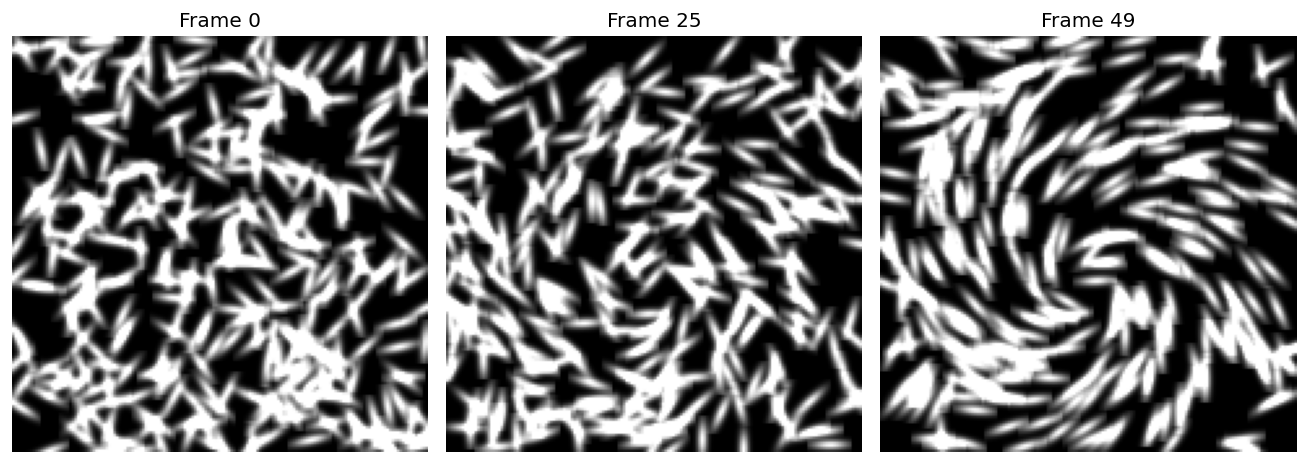

In [2]:
def stamp_rod_cell(frame, cy, cx, angle, length=5.0, width=1.3, intensity=1.0, half_box=8):
    '''Draw one oriented rod-shaped cell as an anisotropic Gaussian.'''
    H, W = frame.shape
    y0 = max(0, int(cy) - half_box); y1 = min(H, int(cy) + half_box + 1)
    x0 = max(0, int(cx) - half_box); x1 = min(W, int(cx) + half_box + 1)
    if y0 >= y1 or x0 >= x1:
        return
    yy, xx = np.mgrid[y0:y1, x0:x1]
    ca, sa = np.cos(angle), np.sin(angle)
    xp = (xx - cx) * ca + (yy - cy) * sa
    yp = -(xx - cx) * sa + (yy - cy) * ca
    frame[y0:y1, x0:x1] += intensity * np.exp(-xp**2 / (2 * length**2) - yp**2 / (2 * width**2))


def vortex_velocity(cy, cx, H, W, omega=0.035, drift_x=0.6):
    '''Uniform drift + rigid-body rotation about the image center.'''
    y_c, x_c = H / 2, W / 2
    dy, dx = cy - y_c, cx - x_c
    vx = drift_x - omega * dy
    vy = omega * dx
    return vy, vx


def simulate_movie(velocity_fn, n_frames=12, shape=(160, 160), n_cells=320, seed=0):
    '''Movie of rod-shaped cells advected by velocity_fn with periodic boundaries.'''
    H, W = shape
    rng = np.random.default_rng(seed)
    cy = rng.uniform(0, H, size=n_cells)
    cx = rng.uniform(0, W, size=n_cells)
    angles = rng.uniform(0, 2 * np.pi, size=n_cells)
    frames = []
    for _ in range(n_frames):
        frame = np.zeros(shape, dtype=np.float32)
        for i in range(n_cells):
            stamp_rod_cell(frame, cy[i], cx[i], angles[i])
        frames.append(np.clip(frame, 0, 1))
        vy, vx = velocity_fn(cy, cx, H, W)
        cy = (cy + vy) % H
        cx = (cx + vx) % W
        # Let the long axis of each cell slowly align with its velocity
        target = np.arctan2(vy, vx)
        diff = (target - angles + np.pi) % (2 * np.pi) - np.pi
        angles = angles + 0.05 * diff
    return frames

synth_frames = simulate_movie(vortex_velocity, n_frames=50)
synth_frames = np.stack(synth_frames, axis=0)
total_t, _, _ = synth_frames.shape
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, t in zip(axes, [0, total_t//2, total_t-1]):
    ax.imshow(synth_frames[t])
    ax.set_title(f'Frame {t}')
    ax.axis('off')
plt.tight_layout()
plt.show()

For better visualization, we produce a .gif file from the simulated data

In [3]:
gif_filename = 'synthetic_movie.gif'

# Convert frames to uint8 for GIF creation
# The frames are already normalized between 0 and 1, so scale by 255
gif_frames = [(frame * 255).astype(np.uint8) for frame in synth_frames]

iio.imwrite(gif_filename, gif_frames, fps=5)
print(f'GIF saved as {gif_filename}')

GIF saved as synthetic_movie.gif


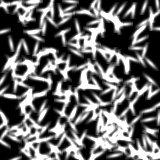

In [4]:
from IPython.display import Image, display
display(Image(filename=gif_filename))

## Farneback on the synthetic movie

We now run Farneback on a pair of successive synthetic frames, visualize the flow with the standard HSV encoding (hue = direction, value = magnitude), and overlay the recovered vectors against the **true** ones at each grid location.

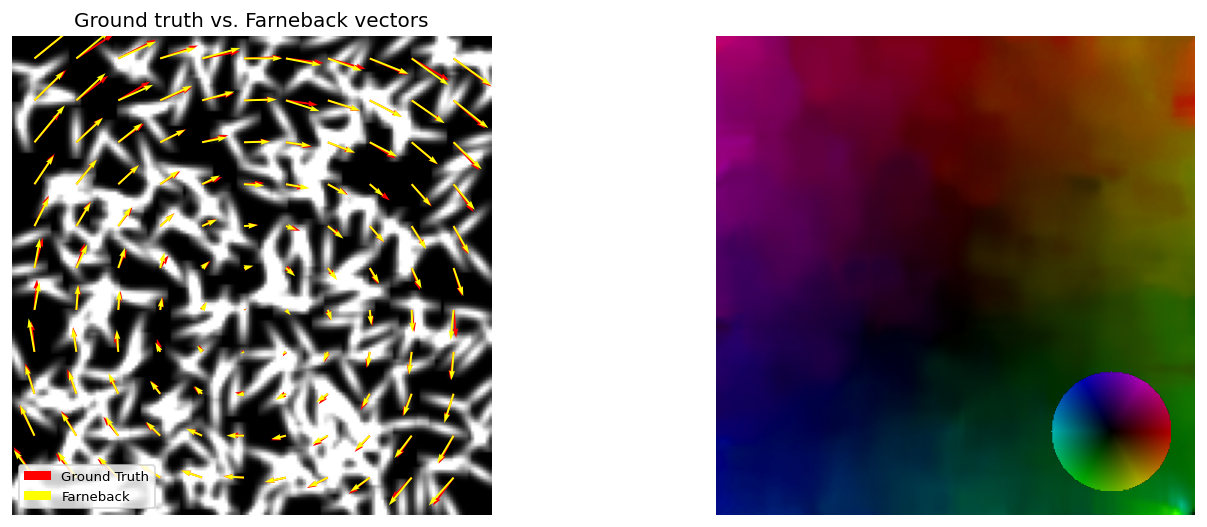

In [5]:
def to_uint8(img):
    return np.clip(img * 255.0, 0, 255).astype(np.uint8)

t0 = 5
prev = to_uint8(synth_frames[t0])
nxt = to_uint8(synth_frames[t0 + 1])
flow = cv2.calcOpticalFlowFarneback(
    prev, nxt, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=5, poly_n=5, poly_sigma=1.2, flags=0,
)
u, v = flow[..., 0], flow[..., 1]

# HSV-encoded flow: hue from angle, value from magnitude
mag, ang = cv2.cartToPolar(u, v)
H, W = u.shape
hsv = np.zeros((H, W, 3), dtype=np.uint8)
hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)
hsv[..., 1] = 255
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# Ground-truth and estimated vectors on a coarse grid
yy, xx = np.mgrid[:H, :W]
vy_true, vx_true = vortex_velocity(yy.astype(float), xx.astype(float), H, W)
step = 14
sl = (slice(step // 2, None, step), slice(step // 2, None, step))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[1].imshow(flow_rgb); axes[0].set_title('Farneback flow (HSV)'); axes[0].axis('off')
# HSV color wheel inset
h_w, w_w = 100, 100
yy_w, xx_w = np.mgrid[-h_w//2:h_w//2, -w_w//2:w_w//2]
mag_w, ang_w = cv2.cartToPolar(xx_w.astype(float), yy_w.astype(float))
hsv_w = np.zeros((h_w, w_w, 3), dtype=np.uint8)
hsv_w[..., 0] = (ang_w * 180 / np.pi / 2).astype(np.uint8)
hsv_w[..., 1] = 255
# Mask circle
mask_w = mag_w <= h_w//2
hsv_w[..., 2] = np.where(mask_w, cv2.normalize(mag_w, None, 0, 255, cv2.NORM_MINMAX).squeeze(), 0).astype(np.uint8)
rgb_w = cv2.cvtColor(hsv_w, cv2.COLOR_HSV2RGB)
rgba_w = np.dstack((rgb_w, mask_w * 255)).astype(np.uint8)
ax_inset = axes[1].inset_axes([0.7, 0.05, 0.25, 0.25])
ax_inset.imshow(rgba_w)
ax_inset.axis('off')
axes[0].imshow(synth_frames[t0]); axes[1].axis('off')
axes[0].quiver(xx[sl], yy[sl], vx_true[sl], -vy_true[sl], color='red', scale=40, width=0.004, label='Ground Truth')
axes[0].quiver(xx[sl], yy[sl], u[sl], -v[sl], color='yellow', scale=40, width=0.004, label='Farneback')
# Proxy artists for legend on quiver plot
#axes[1].plot([], [], color='red',   marker='>', linestyle='None', label='Ground truth')
#axes[1].plot([], [], color='yellow', marker='>', linestyle='None', label='Farneback')
axes[0].legend(loc='lower left', fontsize=8)
axes[0].set_title('Ground truth vs. Farneback vectors')
plt.tight_layout()
plt.show()

## Part 2: PIV and a *Myxococcus xanthus* colony movie

> Copenhagen, Alert, Wingreen, Shaevitz. *Topological defects promote layer formation in *Myxococcus xanthus* colonies*. **Nature Physics** 17, 211-215 (2021). [doi:10.1038/s41567-020-01056-4](https://doi.org/10.1038/s41567-020-01056-4)

We will use **Supplementary Video 1** of this paper. It shows the reflectance field of a dense *M. xanthus* monolayer, in which new holes and new cell layers spontaneously open and close.

We follow the Precept 6 download pattern: `urllib` with a browser `User-Agent`, with a manual-upload fallback if the download fails.

In [6]:
# Download Supplementary Video 1 from the Copenhagen et al. (2021) paper.
URL = 'https://static-content.springer.com/esm/art%3A10.1038%2Fs41567-020-01056-4/MediaObjects/41567_2020_1056_MOESM3_ESM.mp4'
DEST = 'copenhagen2021_movieS1.mp4'

if not os.path.exists(DEST):
    req = urllib.request.Request(
        URL,
        headers={
            'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 '
                          '(KHTML, like Gecko) Chrome/120.0 Safari/537.36',
            'Referer': 'https://www.nature.com/',
        },
    )
    with urllib.request.urlopen(req) as r, open(DEST, 'wb') as f:
        f.write(r.read())

size_mb = os.path.getsize(DEST) / 1e6
print(f'{DEST}: {size_mb:.1f} MB')
assert size_mb > 1, 'Download too small - likely got an HTML error page'

copenhagen2021_movieS1.mp4: 6.4 MB


If the cell above ran and the movie is on Colab, great. If something went wrong, you can manually download the MP4 (Supplementary Video 1 from the paper link above) onto your computer and upload it to Colab, renaming it to `copenhagen2021_movieS1.mp4`.

Raw shape: (241, 384, 512, 3), dtype: uint8
Movie shape (T, Y, X): (241, 192, 256)


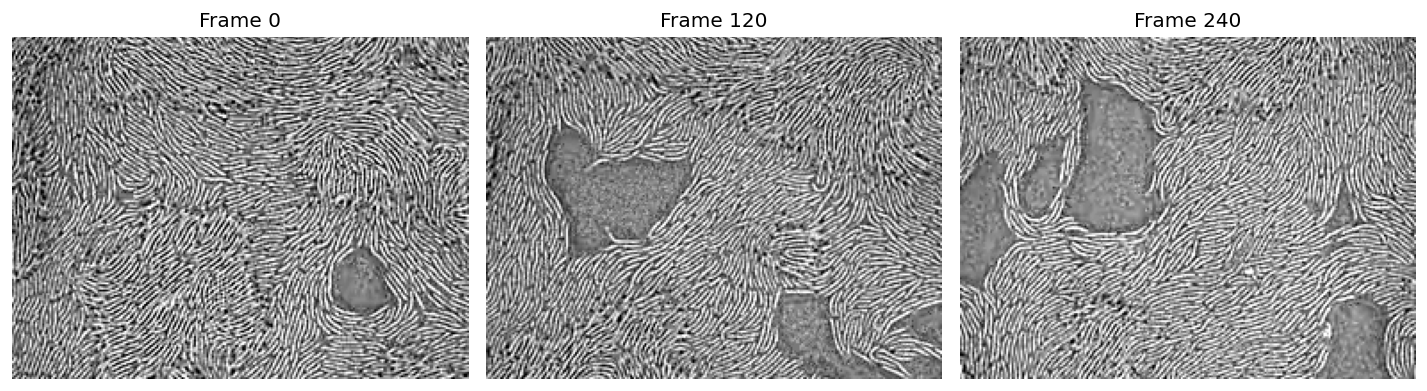

In [12]:
# imageio returns (T, Y, X, 3) for a color MP4. The video is grayscale encoded
# as RGB, so we keep just the first channel.
movie_raw = iio.imread('copenhagen2021_movieS1.mp4')
print(f'Raw shape: {movie_raw.shape}, dtype: {movie_raw.dtype}')
if movie_raw.ndim == 4:
    movie_raw = movie_raw[..., 0]

# Normalize to [0, 255] uint8 for Farneback, using 1/99-percentile clipping
# so that a handful of hot pixels do not compress the useful dynamic range.
def normalize_uint8(stack):
    stack = stack.astype(np.float32)
    lo, hi = np.percentile(stack, [1, 99])
    return np.clip(255 * (stack - lo) / (hi - lo), 0, 255).astype(np.uint8)

movie_u8 = normalize_uint8(movie_raw)
# We crop to the center of the image to not have legends in
_, h, w = movie_u8.shape
movie_u8 = movie_u8[:,h//4:3*h//4,w//4:3*w//4]
print(f'Movie shape (T, Y, X): {movie_u8.shape}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, t in zip(axes, [0, movie_u8.shape[0] // 2, movie_u8.shape[0] - 1]):
    ax.imshow(movie_u8[t])
    ax.set_title(f'Frame {t}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Farneback on the real colony movie

Same function call, applied to a pair of frames from the real movie. We will also compute divergence and curl of the recovered flow, which here do not have a prescribed ground-truth value but are informative all the same: positive divergence highlights regions where the colony is expanding, positive curl highlights counter-clockwise swirls, and so on.

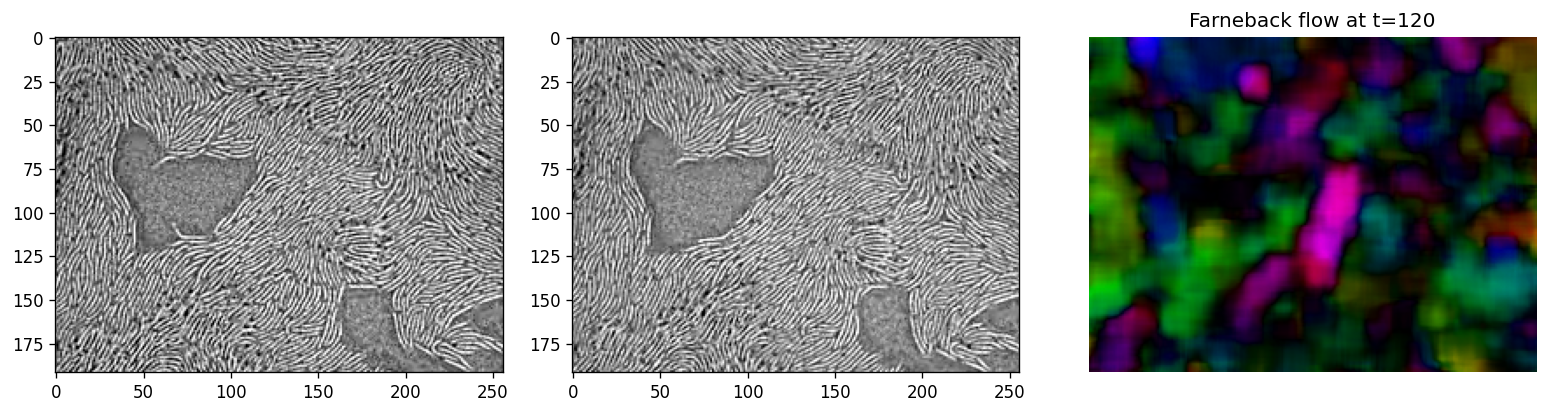

In [13]:
# Pick two successive frames. You may need to adjust t_real depending on how
# fast things are moving in your movie - very slow motion may need frames
# further apart, and very fast motion closer together or even consecutive.
t_real = movie_u8.shape[0] // 2
prev_real = movie_u8[t_real]
nxt_real = movie_u8[t_real + 1]

flow_real = cv2.calcOpticalFlowFarneback(
    prev_real, nxt_real, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=5, poly_n=5, poly_sigma=1.2, flags=0,
)
u_r, v_r = flow_real[..., 0], flow_real[..., 1]

mag_r, ang_r = cv2.cartToPolar(u_r, v_r)
Hr, Wr = u_r.shape
hsv_r = np.zeros((Hr, Wr, 3), dtype=np.uint8)
hsv_r[..., 0] = (ang_r * 180 / np.pi / 2).astype(np.uint8)
hsv_r[..., 1] = 255
hsv_r[..., 2] = cv2.normalize(mag_r, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
flow_rgb_r = cv2.cvtColor(hsv_r, cv2.COLOR_HSV2RGB)

# Smooth + divergence + curl
u_r_sm = ndimage.gaussian_filter(u_r, sigma=3)
v_r_sm = ndimage.gaussian_filter(v_r, sigma=3)
div_r = (ndimage.sobel(u_r_sm, axis=1, mode='reflect') + ndimage.sobel(v_r_sm, axis=0, mode='reflect')) / 8
curl_r = (ndimage.sobel(v_r_sm, axis=1, mode='reflect') - ndimage.sobel(u_r_sm, axis=0, mode='reflect')) / 8

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(prev_real)
axes[1].imshow(nxt_real)
axes[2].imshow(flow_rgb_r); axes[2].set_title(f'Farneback flow at t={t_real}'); axes[2].axis('off')

# Robust color scale (ignore the top/bottom 5% outliers to avoid boundary artifacts washing out the signal)
# vmax = 2 * np.percentile(np.abs(curl_r), 95)
# im1 = axes[1].imshow(div_r, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
# axes[1].set_title('Divergence'); axes[1].axis('off')
# plt.colorbar(im1, ax=axes[1], fraction=0.046)

# im2 = axes[2].imshow(curl_r, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
# axes[2].set_title('Curl'); axes[2].axis('off')
# plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## Part 3: Particle image velocimetry (PIV) from scratch

The optical flow equation starts from brightness constancy in differential form. PIV takes an entirely different route: it starts from **template matching** and builds up from there.

Recall from Lecture 34 that template matching works by sliding a small template across a larger image and scoring how well the template matches at each location - a direct application of 2D cross-correlation. Peaks in the correlation map tell us where the template appears.

PIV is simply template matching applied to pairs of frames:

1. Divide frame $t$ into a grid of small square **interrogation windows** (say 32 x 32 pixels).
2. For each window, take the *same* region from frame $t+1$.
3. Cross-correlate the two patches. The peak of the correlation gives the **displacement** of the patch's content between the two frames.
4. Record that displacement as the velocity vector at the center of the window.

The result is a velocity field evaluated on the grid of window centers - coarser than dense optical flow, but each vector comes with a natural uncertainty estimate (the width and height of the correlation peak). Importantly, the algorithm makes no assumption about brightness constancy *at the pixel level* - only at the *patch* level. This makes it more robust to shot noise and photobleaching than optical flow.

PIV originated in experimental fluid dynamics (tracer particles in a fluid) but works perfectly well on any image that has enough local texture for the correlation peak to be well-defined - which bacterial colonies certainly do.

### A single window, step by step

Before we build the full grid, let's see what the cross-correlation of a single pair of windows looks like.

Patch center in frame 120: (row, col) = (40, 48)
Correlation peak in frame 121: (row, col) = (np.int64(39), np.int64(47))
Displacement: (dy, dx) = (-1, -1) pixels


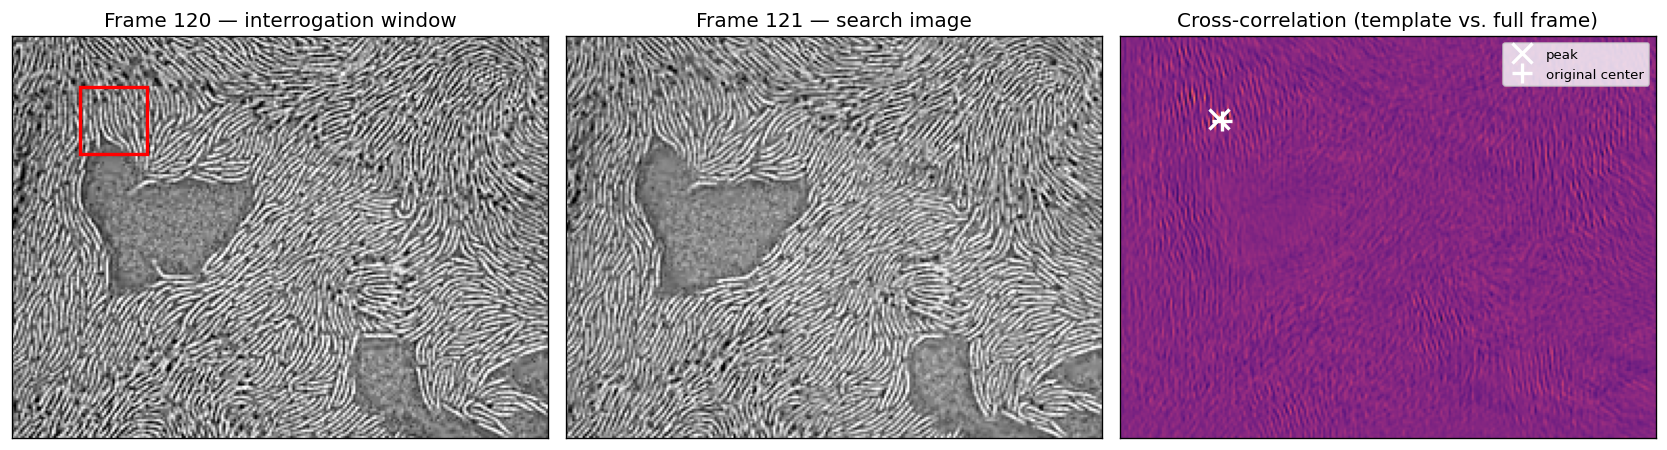

In [14]:
from matplotlib.patches import Rectangle

window_size = 32
# Pick a window somewhere away from the image center, where motion is
# more likely to be visible. Try varying these to sample different regions.
y0 = prev_real.shape[0] // 8
x0 = prev_real.shape[1] // 8
patch1 = prev_real[y0:y0+window_size, x0:x0+window_size].astype(float)

# Subtract the mean to remove DC bias in the correlation
template = patch1 - patch1.mean()
search = nxt_real.astype(float) - nxt_real.astype(float).mean()

# Correlate the small patch against the ENTIRE second frame.
# mode='same' returns a map the same size as the search image,
# so pixel (r, c) in the map tells us how well the template matches
# when centered at (r, c) in frame t+1.
corr = signal.correlate2d(search, template, mode='same')

peak = np.unravel_index(np.argmax(corr), corr.shape)
patch_center_y = y0 + window_size // 2
patch_center_x = x0 + window_size // 2
dy = peak[0] - patch_center_y
dx = peak[1] - patch_center_x
print(f'Patch center in frame {t_real}: (row, col) = ({patch_center_y}, {patch_center_x})')
print(f'Correlation peak in frame {t_real+1}: (row, col) = {peak}')
print(f'Displacement: (dy, dx) = ({dy}, {dx}) pixels')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Panel 1: full frame t with red rectangle highlighting the interrogation window
axes[0].imshow(prev_real)
rect = Rectangle((x0, y0), window_size, window_size,
                  linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title(f'Frame {t_real} — interrogation window')

# Panel 2: full frame t+1 (the search image)
axes[1].imshow(nxt_real)
axes[1].set_title(f'Frame {t_real+1} — search image')

# Panel 3: correlation of template vs. entire frame t+1
axes[2].imshow(corr, cmap='magma')
axes[2].plot(peak[1], peak[0], 'wx', ms=12, mew=2, label='peak')
axes[2].plot(patch_center_x, patch_center_y, 'w+', ms=12, mew=2, label='original center')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].set_title('Cross-correlation (template vs. full frame)')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### Looping over the grid

Now we repeat that process for every window position on a regular grid. The two tuning knobs are the **window size** (bigger = more robust peak, fewer vectors) and the **step** between adjacent window origins (smaller step = denser grid, but adjacent windows become increasingly correlated).

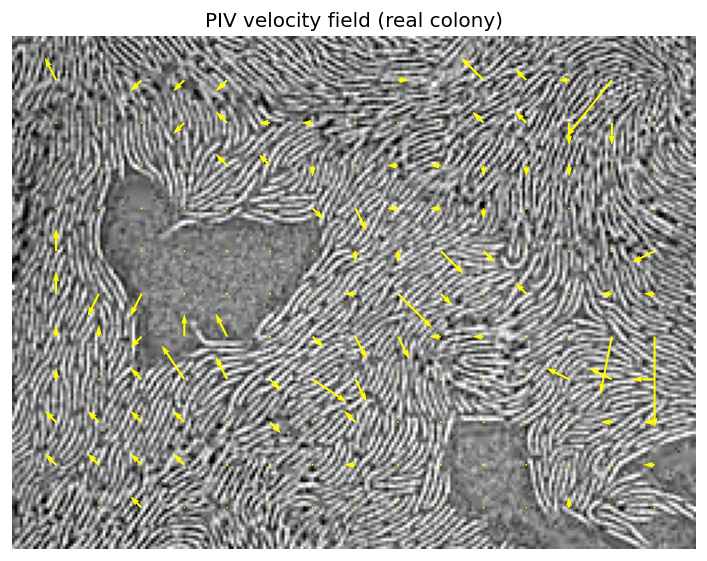

In [15]:
def piv_displacement(patch1, patch2):
    '''Cross-correlate two equal-sized patches and return the integer (dy, dx) of the peak.'''
    p1 = patch1 - patch1.mean()
    p2 = patch2 - patch2.mean()
    corr = signal.correlate2d(p2, p1, mode='full')
    peak = np.unravel_index(np.argmax(corr), corr.shape)
    center = (corr.shape[0] // 2, corr.shape[1] // 2)
    return peak[0] - center[0], peak[1] - center[1]


def run_piv(frame1, frame2, window_size=32, step=16):
    '''Run PIV on a pair of frames, returning grid centers and displacement components.'''
    H, W = frame1.shape
    ys = np.arange(0, H - window_size + 1, step)
    xs = np.arange(0, W - window_size + 1, step)
    u_grid = np.zeros((len(ys), len(xs)))
    v_grid = np.zeros((len(ys), len(xs)))
    f1 = frame1.astype(float)
    f2 = frame2.astype(float)
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            dy, dx = piv_displacement(f1[y:y+window_size, x:x+window_size],
                                      f2[y:y+window_size, x:x+window_size])
            u_grid[i, j] = dx
            v_grid[i, j] = dy
    ys_c = ys + window_size // 2
    xs_c = xs + window_size // 2
    return ys_c, xs_c, u_grid, v_grid


ys_piv, xs_piv, u_piv, v_piv = run_piv(prev_real, nxt_real, window_size=32, step=16)
xx_piv, yy_piv = np.meshgrid(xs_piv, ys_piv)

plt.figure(figsize=(6, 6))
plt.imshow(prev_real)
plt.quiver(xx_piv, yy_piv, u_piv, v_piv, color='yellow', scale=60, width=0.003)
plt.title('PIV velocity field (real colony)')
plt.axis('off')
plt.tight_layout()
plt.show()

## PIV vs Farneback on the same frame pair

To compare the two methods fairly, we evaluate Farneback on the same coarse grid PIV is using and plot them side by side.

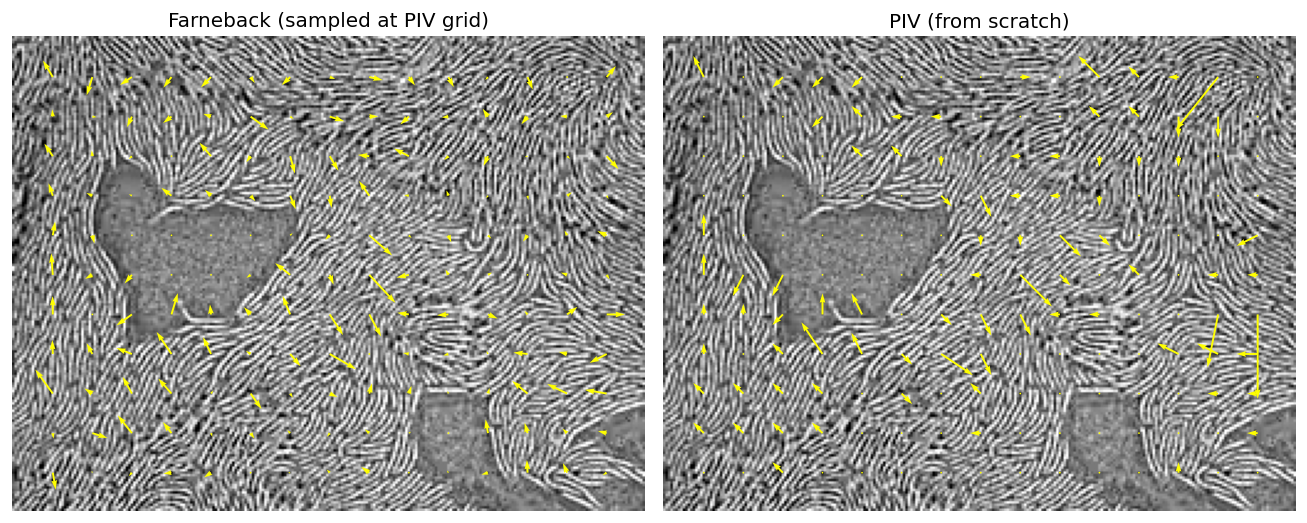

Farneback speeds: mean=0.98, median=0.82 px/frame
PIV speeds:       mean=0.88, median=1.00 px/frame
Mean disagreement between PIV and Farneback: 0.98 px


In [16]:
# Sample the dense Farneback field at the PIV grid centers
u_farn_grid = u_r[ys_piv[:, None], xs_piv[None, :]]
v_farn_grid = v_r[ys_piv[:, None], xs_piv[None, :]]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(prev_real)
axes[0].quiver(xx_piv, yy_piv, u_farn_grid, v_farn_grid, color='yellow', scale=60, width=0.003)
axes[0].set_title('Farneback (sampled at PIV grid)')
axes[0].axis('off')
axes[1].imshow(prev_real)
axes[1].quiver(xx_piv, yy_piv, u_piv, v_piv, color='yellow', scale=60, width=0.003)
axes[1].set_title('PIV (from scratch)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Summary statistics
speed_farn = np.hypot(u_farn_grid, v_farn_grid)
speed_piv = np.hypot(u_piv, v_piv)
print(f'Farneback speeds: mean={speed_farn.mean():.2f}, median={np.median(speed_farn):.2f} px/frame')
print(f'PIV speeds:       mean={speed_piv.mean():.2f}, median={np.median(speed_piv):.2f} px/frame')

# Vector agreement
diff = np.hypot(u_piv - u_farn_grid, v_piv - v_farn_grid)
print(f'Mean disagreement between PIV and Farneback: {diff.mean():.2f} px')

## Exercise: window size and the bias-variance tradeoff in PIV

The **window size** is the single most important knob in PIV. Small windows give you many independent vectors but each one is based on less texture, so the correlation peak is weaker and noisier. Large windows give you fewer vectors but each one averages over a larger region, smoothing out real spatial variation.

Your task:

1. Run `run_piv` on the same real frame pair with at least three different window sizes (e.g. 16, 32, 64). Keep the `step` as `window_size // 2` in each case so that the grid spacing scales with the window.
2. For each result, plot the quiver field over `prev_real`, and print the number of vectors produced.
3. Qualitatively: at what window size does the flow structure start to become visible above the noise? At what size does the spatial detail start to get washed out?
4. Bonus: pick one location in the image and look at what each window size reports as the velocity at that location. How consistent are they?

In [ ]:
# Scaffold for the window-size sweep

window_sizes = [16, 32, 64]  # TODO try more/different values

fig, axes = plt.subplots(1, len(window_sizes), figsize=(5 * len(window_sizes), 5))
for ax, ws in zip(axes, window_sizes):
    # TODO: run PIV with this window size and step=ws//2, store the result,
    # and plot the quiver field over prev_real on `ax`. Title the axis with
    # the window size and the number of vectors produced.
    pass

plt.tight_layout()
plt.show()